In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Applying the Tolerance Principle to BADs

In [63]:
def read_compounds(path):
    """Read in a compounds file and return a pandas dataframe"""
    df = pd.read_csv(path, sep="\t", header=None,
                     names=["compound", "constituents", "e_interfixation", "frequency"])
    return df

def read_past_tense(path):
    """Read in a past tense file and return a pandas dataframe"""
    df = pd.read_csv(path, sep="\t", header=None, names=["lemma", "inflected", "ing", "ing_ang", "frequency"])
    return df

In [64]:
def tp(n, e):
    """Test for productivity"""
    if n <= 1:
        return False
    return e <= n / np.log(n) and e < n / 2

def sample_weighted(df, col_name, sample_size=100, reps=1000):
    """Repeatedly sample from the dataframe to see if it's productive"""
    samples = []
    for _ in range(reps):
        sample = df.sample(n=sample_size, replace=False, weights=df["frequency"])
        count = sample[col_name].sum()
        samples.append(tp(sample_size, sample_size - count))
    return sum(samples) / len(samples)

def sample_weight_past(df, sample_size=100, reps=1000):
    """Repeatedly sample from the dataframe to see if it's productive"""
    samples = []
    for _ in range(reps):
        sample = df.sample(n=sample_size, replace=False, weights=df["frequency"])
        count = sample["ing_ang"].sum()
        n = sample["ing"].sum()
        samples.append(tp(n, n - count))
    return sum(samples) / len(samples)




# German -e- Interfixation

In [65]:
compounds = read_compounds("data/compounds.txt")
compounds

,compound,constituents,e_interfixation,frequency
0,Eisenbahn,Eisen+Bahn,False,2066
1,Flugzeug,Flug+Zeug,False,2037
2,Bahnhof,Bahn+Hof,False,1123
3,Geburtstag,Geburt+s+Tag,False,1019
4,Feuerwehr,Feuer+Wehr,False,821
...,...,...,...,...
1356,Handgriff,Hand+Griff,False,1
1357,Brachvogel,Brache+Vogel,True,1
1358,Regentonne,Regen+Tonne,False,1
1359,Butterblume,Butter+Blume,False,1


In [66]:
percents = []
sizes = range(5, 500, 1)
for size in sizes:
    percents.append(sample_weighted(compounds, "e_interfixation", size))

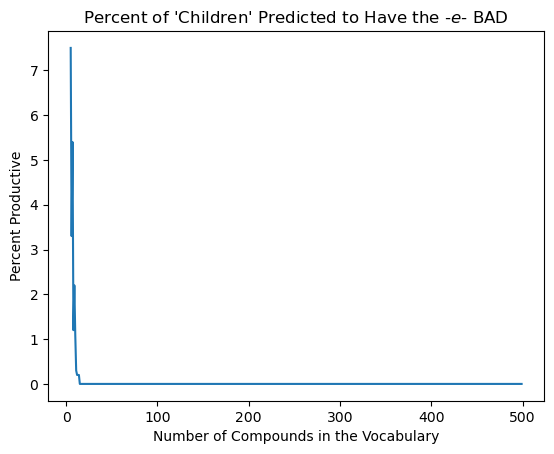

In [67]:
plt.plot(list(sizes), [p * 100 for p in percents])
plt.title(r"Percent of 'Children' Predicted to Have the -$e$- BAD")
plt.xlabel("Number of Compounds in the Vocabulary")
plt.ylabel("Percent Productive")
plt.savefig("data/tp-compounds.png", dpi=300)

# English ing-ang

In [68]:
past_tense = read_past_tense("data/eng-past.txt")
past_tense[past_tense["ing"] == True]

,lemma,inflected,ing,ing_ang,frequency
21,bring,brought,True,False,1026
113,sing,sang,True,True,110
164,sting,stung,True,False,50
184,ring,rang,True,True,40
512,spring,sprang,True,True,4
523,ding,dinged,True,False,4
524,swing,swung,True,False,4
549,string,strung,True,False,3
684,fling,flung,True,False,2
856,wing,winged,True,False,1


In [69]:
percents = []
sizes = range(5, 1000, 1)
for size in sizes:
    percents.append(sample_weight_past(past_tense, size))

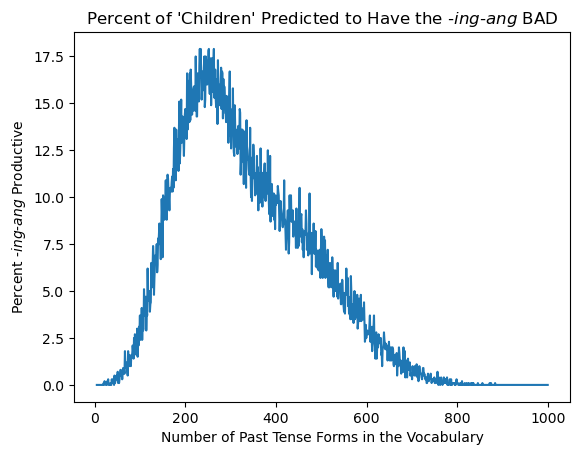

In [70]:
plt.plot(list(sizes), [p * 100 for p in percents])
plt.title(r"Percent of 'Children' Predicted to Have the -$\mathit{ing}$-$\mathit{ang}$ BAD")
plt.xlabel("Number of Past Tense Forms in the Vocabulary")
plt.ylabel(r"Percent -$\mathit{ing}$-$\mathit{ang}$ Productive")
plt.savefig("data/tp-past.png", dpi=300)